In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [2]:
df = pd.read_csv("default_credit_card_clients.csv")
df = df.drop("Unnamed: 0", axis=1)
df = df.drop(0)
df['Y'] = df['Y'].astype(int)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   X1      30000 non-null  object
 1   X2      30000 non-null  object
 2   X3      30000 non-null  object
 3   X4      30000 non-null  object
 4   X5      30000 non-null  object
 5   X6      30000 non-null  object
 6   X7      30000 non-null  object
 7   X8      30000 non-null  object
 8   X9      30000 non-null  object
 9   X10     30000 non-null  object
 10  X11     30000 non-null  object
 11  X12     30000 non-null  object
 12  X13     30000 non-null  object
 13  X14     30000 non-null  object
 14  X15     30000 non-null  object
 15  X16     30000 non-null  object
 16  X17     30000 non-null  object
 17  X18     30000 non-null  object
 18  X19     30000 non-null  object
 19  X20     30000 non-null  object
 20  X21     30000 non-null  object
 21  X22     30000 non-null  object
 22  X23     30000 non-null

,Y
count,30000.000000
mean,0.221200
std,0.415062
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [4]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23', 'Y'],
      dtype='object')

In [5]:
df.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

In [6]:
df['Y'].value_counts()

Y
0    23364
1     6636
Name: count, dtype: int64

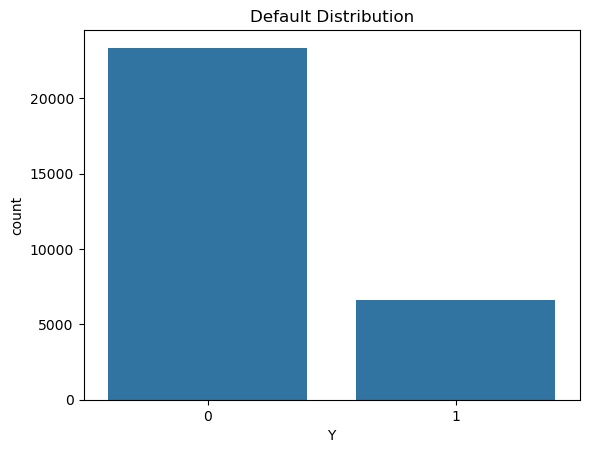

In [7]:
sns.countplot(x='Y', data=df)
plt.title("Default Distribution")
plt.show()

In [8]:
X = df.drop('Y', axis=1)
y = df['Y']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

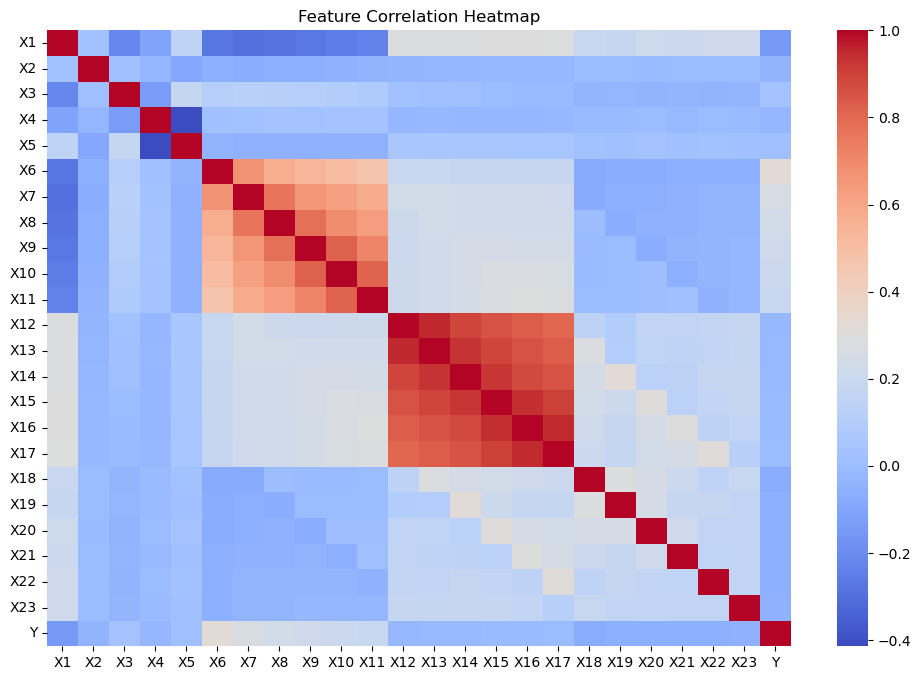

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.savefig('my_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

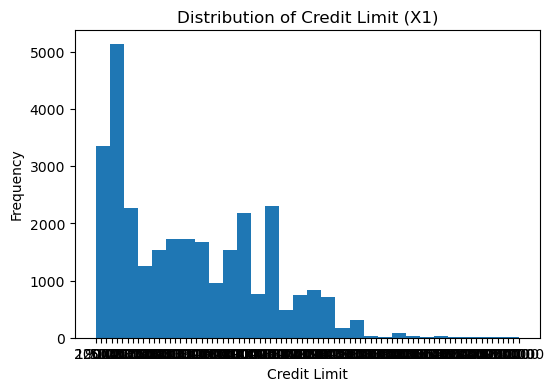

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['X1'], bins=30)
plt.title("Distribution of Credit Limit (X1)")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

In [16]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

In [17]:
cm = confusion_matrix(y_test, y_pred_lda)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4529  158]
 [ 988  325]]


In [18]:
accuracy = accuracy_score(y_test, y_pred_lda)

print("Accuracy:", accuracy)

Accuracy: 0.809


In [19]:
print(classification_report(y_test, y_pred_lda))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.67      0.25      0.36      1313

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



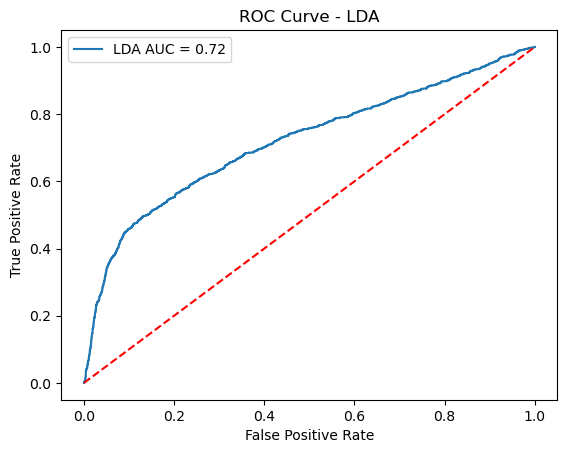

In [20]:
y_prob = lda.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="LDA AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LDA")
plt.legend()
plt.show()

In [21]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [22]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[4549  138]
 [1004  309]]


In [23]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)

Accuracy: 0.8096666666666666


In [24]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



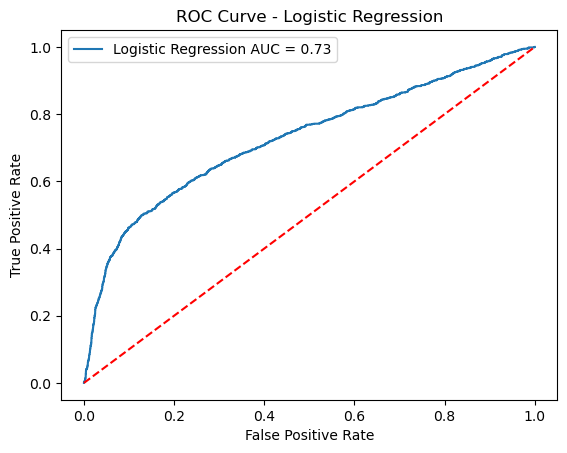

In [25]:
y_prob_lr = lr.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression AUC = %0.2f" % roc_auc_lr)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [26]:
svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Prediction completed")

Prediction completed


In [27]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[4482  205]
 [ 877  436]]


In [28]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)

Accuracy: 0.8196666666666667


In [29]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4687
           1       0.68      0.33      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



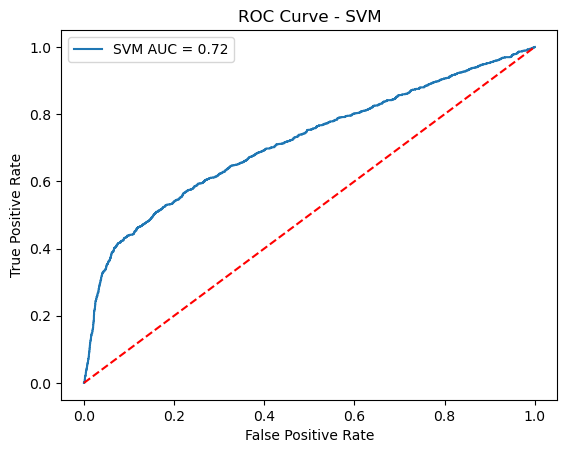

In [30]:
y_prob_svm = svm.predict_proba(X_test)[:,1]

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)

roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_svm, tpr_svm, label="SVM AUC = %0.2f" % roc_auc_svm)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest model trained")

Random Forest model trained


In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[4420  267]
 [ 842  471]]


In [33]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)

Accuracy: 0.8151666666666667


In [34]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.36      0.46      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



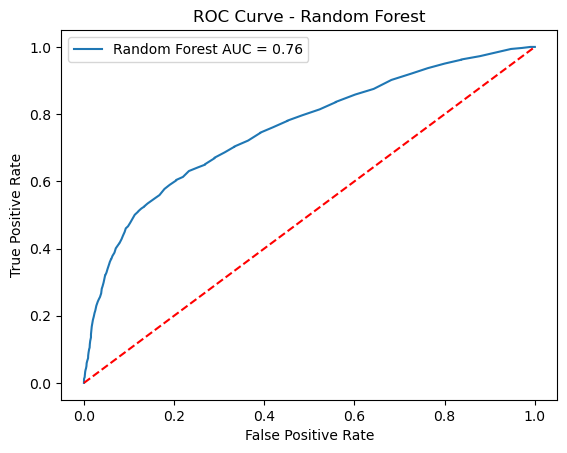

In [35]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

roc_auc_rf = auc(fpr_rf, tpr_rf)

import matplotlib.pyplot as plt

plt.plot(fpr_rf, tpr_rf, label="Random Forest AUC = %0.2f" % roc_auc_rf)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [36]:
!pip install xgboost

In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost model trained")

XGBoost model trained


In [38]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm_xgb)

Confusion Matrix:
[[4413  274]
 [ 837  476]]


In [39]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("Accuracy:", accuracy_xgb)

Accuracy: 0.8148333333333333


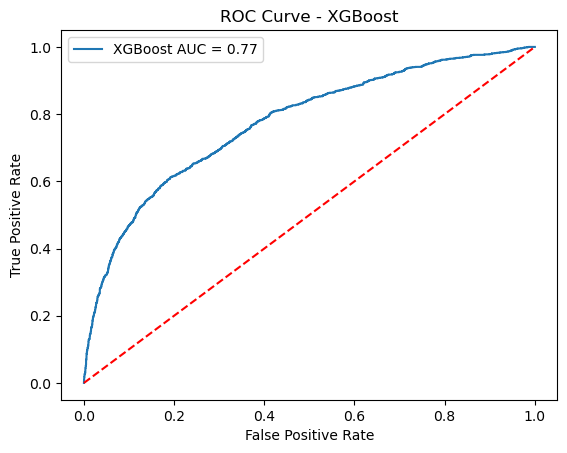

In [40]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.plot(fpr_xgb, tpr_xgb, label="XGBoost AUC = %0.2f" % roc_auc_xgb)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [41]:
!pip install tensorflow

In [42]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [44]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7959 - loss: 0.4907
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8163 - loss: 0.4492
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8182 - loss: 0.4419
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8198 - loss: 0.4374
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8207 - loss: 0.4348
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8205 - loss: 0.4329
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8202 - loss: 0.4313
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8216 - loss: 0.4297
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8215 - loss: 0.4290
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8217 - loss: 0.4281
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8204 - loss: 0.4274
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [45]:
y_prob_dnn = model.predict(X_test)

y_pred_dnn = (y_prob_dnn > 0.5)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [46]:
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

print("Confusion Matrix:")
print(cm_dnn)

Confusion Matrix:
[[4435  252]
 [ 837  476]]


In [47]:
accuracy_dnn = accuracy_score(y_test, y_pred_dnn)

print("Accuracy:", accuracy_dnn)

Accuracy: 0.8185


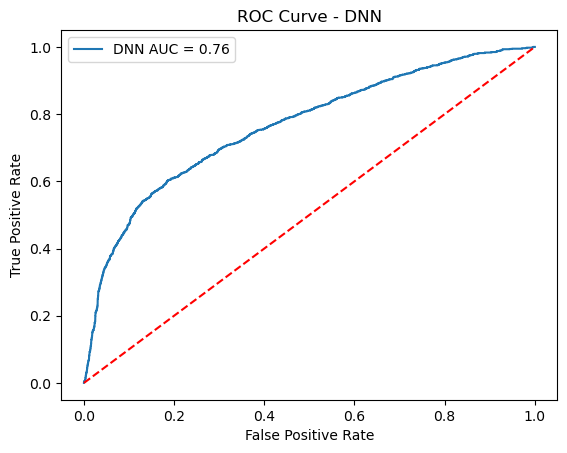

In [48]:
fpr_dnn, tpr_dnn, thresholds_dnn = roc_curve(y_test, y_prob_dnn)

roc_auc_dnn = auc(fpr_dnn, tpr_dnn)

import matplotlib.pyplot as plt

plt.plot(fpr_dnn, tpr_dnn, label="DNN AUC = %0.2f" % roc_auc_dnn)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DNN")
plt.legend()
plt.show()

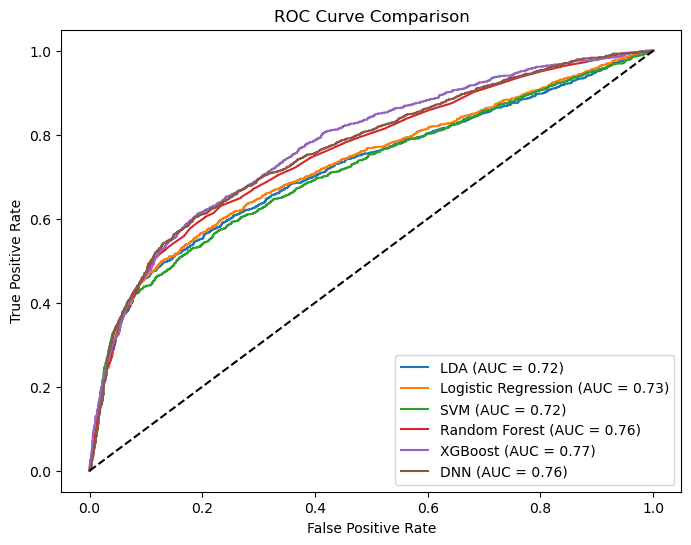

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# LDA
plt.plot(fpr, tpr, label="LDA (AUC = %0.2f)" % roc_auc)

# Logistic Regression
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (AUC = %0.2f)" % roc_auc_lr)

# SVM
plt.plot(fpr_svm, tpr_svm, label="SVM (AUC = %0.2f)" % roc_auc_svm)

# Random Forest
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = %0.2f)" % roc_auc_rf)

# XGBoost
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost (AUC = %0.2f)" % roc_auc_xgb)

# DNN
plt.plot(fpr_dnn, tpr_dnn, label="DNN (AUC = %0.2f)" % roc_auc_dnn)


plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [50]:
import pandas as pd
import matplotlib.pyplot as plt


feature_map = {
    'X1':'LIMIT_BAL','X2':'SEX','X3':'EDUCATION','X4':'MARRIAGE','X5':'AGE',
    'X6':'PAY_0','X7':'PAY_2','X8':'PAY_3','X9':'PAY_4','X10':'PAY_5','X11':'PAY_6',
    'X12':'BILL_AMT1','X13':'BILL_AMT2','X14':'BILL_AMT3','X15':'BILL_AMT4','X16':'BILL_AMT5','X17':'BILL_AMT6',
    'X18':'PAY_AMT1','X19':'PAY_AMT2','X20':'PAY_AMT3','X21':'PAY_AMT4','X22':'PAY_AMT5','X23':'PAY_AMT6'
}


importances = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})


feature_importance['Feature'] = feature_importance['Feature'].map(feature_map)

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

      Feature  Importance
5       PAY_0    0.094356
4         AGE    0.066265
11  BILL_AMT1    0.059704
0   LIMIT_BAL    0.058161
12  BILL_AMT2    0.054228
13  BILL_AMT3    0.051720
17   PAY_AMT1    0.051650
16  BILL_AMT6    0.050848
15  BILL_AMT5    0.050269
14  BILL_AMT4    0.049792
18   PAY_AMT2    0.047338
19   PAY_AMT3    0.046180
22   PAY_AMT6    0.046130
6       PAY_2    0.043941
20   PAY_AMT4    0.043396
21   PAY_AMT5    0.043361
7       PAY_3    0.032044
9       PAY_5    0.023870
8       PAY_4    0.022364
2   EDUCATION    0.020784
10      PAY_6    0.017107
3    MARRIAGE    0.014037
1         SEX    0.012454


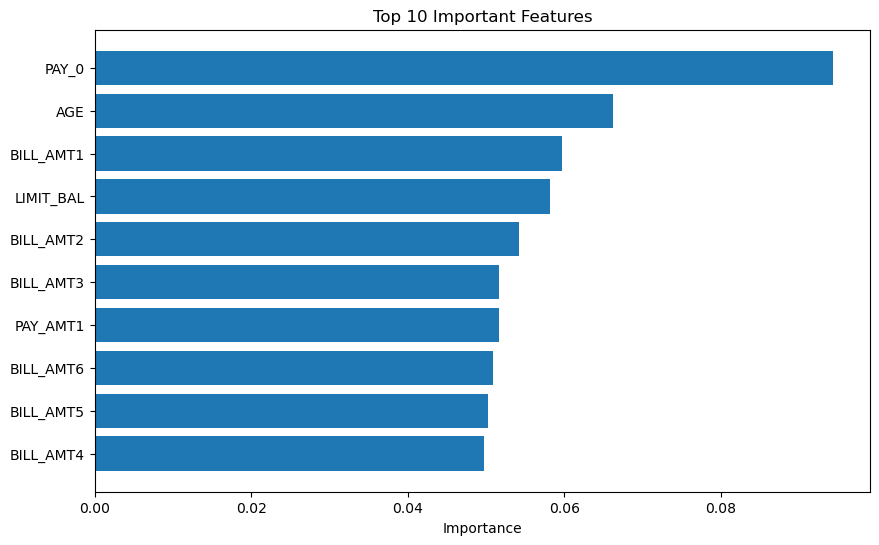

In [51]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

In [52]:
from sklearn.model_selection import cross_val_score

cv_scores_rf = cross_val_score(rf, X_scaled, y, cv=10)

print("Random Forest CV Accuracy:", cv_scores_rf.mean())
print("Standard Deviation:", cv_scores_rf.std())

cv_scores_lr = cross_val_score(lr, X_scaled, y, cv=10)

print("Logistic Regression CV Accuracy:", cv_scores_lr.mean())
print("Standard Deviation:", cv_scores_lr.std())

Random Forest CV Accuracy: 0.8158
Standard Deviation: 0.008885943956609226
Logistic Regression CV Accuracy: 0.8096666666666668
Standard Deviation: 0.0070820587088469816


In [53]:
from sklearn.metrics import confusion_matrix
import numpy as np


tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()


specificity = tn / (tn + fp)


sensitivity = tp / (tp + fn)


g_mean = np.sqrt(sensitivity * specificity)

print("Specificity:", specificity)
print("G-Mean:", g_mean)

Specificity: 0.9430339236185193
G-Mean: 0.5816232360786732


In [54]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, f1_score

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)   # recall
    precision = tp / (tp + fp)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    
    g_mean = np.sqrt(sensitivity * specificity)
    
    return specificity, sensitivity, precision, f1, g_mean

In [55]:

spec_lda, sens_lda, prec_lda, f1_lda, g_lda = calculate_metrics(y_test, y_pred_lda)


spec_lr, sens_lr, prec_lr, f1_lr, g_lr = calculate_metrics(y_test, y_pred_lr)


spec_svm, sens_svm, prec_svm, f1_svm, g_svm = calculate_metrics(y_test, y_pred_svm)


spec_rf, sens_rf, prec_rf, f1_rf, g_rf = calculate_metrics(y_test, y_pred_rf)


spec_xgb, sens_xgb, prec_xgb, f1_xgb, g_xgb = calculate_metrics(y_test, y_pred_xgb)


spec_dnn, sens_dnn, prec_dnn, f1_dnn, g_dnn = calculate_metrics(y_test, y_pred_dnn)

In [56]:
import pandas as pd

results_metrics = pd.DataFrame({
    'Model': ['LDA','Logistic Regression','SVM','Random Forest','XGBoost','DNN'],
    
    'Accuracy': [
        accuracy,
        accuracy_lr,
        accuracy_svm,
        accuracy_rf,
        accuracy_xgb,
        accuracy_dnn
    ],
    
    'AUC': [
        roc_auc,
        roc_auc_lr,
        roc_auc_svm,
        roc_auc_rf,
        roc_auc_xgb,
        roc_auc_dnn
    ],

    'Specificity': [spec_lda, spec_lr, spec_svm, spec_rf, spec_xgb, spec_dnn],
    'Sensitivity': [sens_lda, sens_lr, sens_svm, sens_rf, sens_xgb, sens_dnn],
    'Precision': [prec_lda, prec_lr, prec_svm, prec_rf, prec_xgb, prec_dnn],
    'F1-Score': [f1_lda, f1_lr, f1_svm, f1_rf, f1_xgb, f1_dnn],
    'G-Mean': [g_lda, g_lr, g_svm, g_rf, g_xgb, g_dnn]
})

print(results_metrics)

                 Model  Accuracy       AUC  Specificity  Sensitivity  \
0                  LDA  0.809000  0.718763     0.966290     0.247525   
1  Logistic Regression  0.809667  0.726975     0.970557     0.235339   
2                  SVM  0.819667  0.715048     0.956262     0.332064   
3        Random Forest  0.815167  0.757340     0.943034     0.358720   
4              XGBoost  0.814833  0.774960     0.941540     0.362529   
5                  DNN  0.818500  0.764603     0.946234     0.362529   

   Precision  F1-Score    G-Mean  
0   0.672878  0.361915  0.489061  
1   0.691275  0.351136  0.477922  
2   0.680187  0.446264  0.563507  
3   0.638211  0.459288  0.581623  
4   0.634667  0.461464  0.584239  
5   0.653846  0.466438  0.585694  


In [57]:
!pip install shap

In [58]:
import shap
shap.initjs()
# Initialize explainer
explainer = shap.Explainer(xgb, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)

 97%|=================== | 5822/6000 [00:21<00:00]       

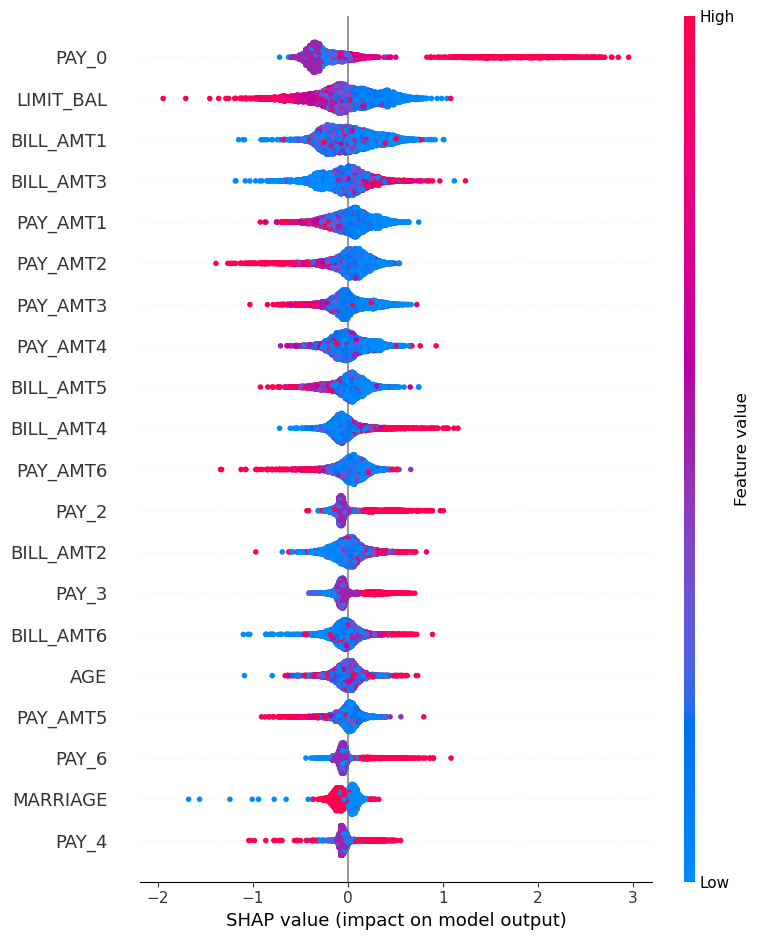

In [59]:
X_test_named = pd.DataFrame(X_test, columns=X.columns)

feature_map = {
    'X1':'LIMIT_BAL','X2':'SEX','X3':'EDUCATION','X4':'MARRIAGE','X5':'AGE',
    'X6':'PAY_0','X7':'PAY_2','X8':'PAY_3','X9':'PAY_4','X10':'PAY_5','X11':'PAY_6',
    'X12':'BILL_AMT1','X13':'BILL_AMT2','X14':'BILL_AMT3','X15':'BILL_AMT4','X16':'BILL_AMT5','X17':'BILL_AMT6',
    'X18':'PAY_AMT1','X19':'PAY_AMT2','X20':'PAY_AMT3','X21':'PAY_AMT4','X22':'PAY_AMT5','X23':'PAY_AMT6'
}

X_test_named.columns = [feature_map[col] for col in X_test_named.columns]

shap.summary_plot(shap_values, X_test_named,show=False)
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

In [61]:
shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    X_test_named.iloc[0]
) 

In [64]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))